# Part 1: Submitting Jobs to Simulators with qBraid

The **qBraid SDK** is our flagship Python toolkit for running platform-agnostic quantum programs. The `qbraid.runtime` module provides a unified interface to multiple quantum software packages (Qiskit, Cirq, etc.) and their respective cloud vendors (AWS, Azure, etc.).

### Learning Objectives

By the end of this notebook, you will be able to:

1. Use the `QbraidProvider` to discover available quantum devices
2. Build quantum circuits using **Cirq** and **Qiskit**
3. Submit circuits to the **AWS SV1 Statevector Simulator** via qBraid
4. Retrieve and visualize measurement results
5. Understand how qBraid bridges different quantum libraries to a common execution backend

In [1]:
import qbraid

qbraid.__version__

'0.11.1'

In [2]:
import warnings
warnings.filterwarnings("ignore")

## What is a Quantum Simulator?

A **quantum simulator** is a classical computer program that mathematically models the behavior of a quantum system. Simulators are essential tools for quantum development because they provide:

- **Ideal results** — no noise, no hardware errors, no decoherence
- **Fast iteration** — run circuits instantly without waiting in hardware queues
- **Debugging** — verify your circuit logic before spending money on real hardware

The **AWS SV1 Statevector Simulator** is a cloud-hosted simulator that can simulate up to 34 qubits. It computes the full quantum state vector, giving exact probability distributions.

## Using the `QbraidProvider` and Devices

The **Provider** abstraction groups together all quantum devices accessible through qBraid. Each provider exposes a list of supported devices (simulators and QPUs) that can be retrieved with `.get_devices()`.

Device IDs follow the **QRN (qBraid Resource Name)** format: `cloud:vendor:type:name`  
For example: `aws:aws:sim:sv1` means *AWS cloud, AWS vendor, simulator, SV1*.

In [3]:
from qbraid.runtime import QbraidProvider

provider = QbraidProvider()

In [4]:
provider.get_devices()

[<qbraid.runtime.native.device.QbraidDevice('aws:aqt:qpu:ibex-q1')>,
 <qbraid.runtime.native.device.QbraidDevice('aws:quera:qpu:aquila')>,
 <qbraid.runtime.native.device.QbraidDevice('aws:ionq:qpu:aria-1')>,
 <qbraid.runtime.native.device.QbraidDevice('azure:ionq:qpu:aria-1')>,
 <qbraid.runtime.native.device.QbraidDevice('aws:rigetti:qpu:ankaa-3')>,
 <qbraid.runtime.native.device.QbraidDevice('aws:aws:sim:tn1')>,
 <qbraid.runtime.native.device.QbraidDevice('aws:aws:sim:dm1')>,
 <qbraid.runtime.native.device.QbraidDevice('qbraid:nec:sim:vector-annealer')>,
 <qbraid.runtime.native.device.QbraidDevice('azure:quantinuum:sim:h2-1e')>,
 <qbraid.runtime.native.device.QbraidDevice('azure:rigetti:qpu:ankaa-3')>,
 <qbraid.runtime.native.device.QbraidDevice('azure:pasqal:qpu:fresnel')>,
 <qbraid.runtime.native.device.QbraidDevice('azure:pasqal:sim:emu-tn')>,
 <qbraid.runtime.native.device.QbraidDevice('aws:iqm:qpu:emerald')>,
 <qbraid.runtime.native.device.QbraidDevice('azure:ionq:qpu:forte-1')>,

### Choose the AWS Statevector Simulator

We select the **SV1** simulator using its QRN device ID. The `_target_spec` attribute tells us which circuit formats this device accepts natively — qBraid will automatically transpile our circuits to a supported format.

In [5]:
aws_sim = provider.get_device("aws:aws:sim:sv1")
aws_sim

<qbraid.runtime.native.device.QbraidDevice('aws:aws:sim:sv1')>

In [ ]:
aws_sim._target_spec

## Define the Quantum Circuit

We will build a circuit that prepares the [**Bell state**](https://en.wikipedia.org/wiki/Bell_state):

$$ |\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}} $$

This is one of the simplest examples of **quantum entanglement** — measuring one qubit instantly determines the state of the other. The circuit requires just two gates:

1. **Hadamard (H)** on qubit 0 — creates a superposition $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$
2. **CNOT (CX)** with qubit 0 as control and qubit 1 as target — entangles both qubits

On a perfect simulator, we expect to see only two outcomes: `|00>` and `|11>`, each with ~50% probability.

---

## Running on Simulator: AWS Statevector Simulator

We will build the same Bell circuit using two different quantum libraries — **Cirq** and **Qiskit** — and submit both to the same AWS SV1 simulator through qBraid. This demonstrates qBraid's ability to bridge different quantum frameworks to a common backend.

### Submit Cirq Circuit to AWS Simulator

**Cirq** is Google's open-source quantum computing library. It uses `LineQubit` objects and builds circuits by appending gate operations.

In [6]:
import cirq

# Create 2 qubits
qubits = [cirq.LineQubit(i) for i in range(2)]

# Define the circuit
bell_circuit = cirq.Circuit()

# Apply a Hadamard gate to the first qubit
bell_circuit.append(cirq.H(qubits[0]))

# Apply CNOT gate to entangle the qubits
bell_circuit.append(cirq.CNOT(qubits[0], qubits[1]))

# Measure all qubits
bell_circuit.append(cirq.measure(*qubits, key="result"))

In [7]:
print(bell_circuit)

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────


#### Execute Cirq Circuit on AWS Simulator

Note that the SV1 device natively accepts **Braket** circuits, but qBraid automatically transpiles our Cirq circuit behind the scenes.

In [8]:
job_cirq = aws_sim.run(bell_circuit, shots=1000)
cirq_counts = job_cirq.result().data.get_counts()
print("Cirq counts:", cirq_counts)

Cirq counts: {'00': 502, '11': 498}


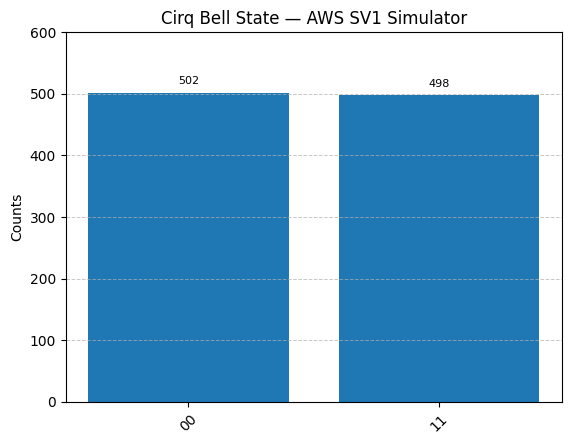

In [9]:
from qbraid.visualization import plot_histogram

plot_histogram(cirq_counts, title="Cirq Bell State — AWS SV1 Simulator")

### Submit Qiskit Circuit to AWS Simulator

**Qiskit** is IBM's open-source quantum computing library. It uses a `QuantumCircuit` class where gates are applied by calling methods like `.h()` and `.cx()`.

Despite the different syntax, we are building the exact same Bell state circuit.

In [10]:
from qiskit import QuantumCircuit

# Create a 2-qubit quantum circuit
qiskit_qc = QuantumCircuit(2)

qiskit_qc.h(0)
qiskit_qc.cx(0, 1)

qiskit_qc.measure_all()

In [11]:
print(qiskit_qc)

        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


#### Execute Qiskit Circuit on AWS Simulator

Same process — qBraid transpiles the Qiskit circuit to Braket format and runs it on SV1.

In [12]:
job_qiskit = aws_sim.run(qiskit_qc, shots=1000)
qiskit_counts = job_qiskit.result().data.get_counts()
print("Qiskit counts:", qiskit_counts)

Qiskit counts: {'00': 506, '11': 494}


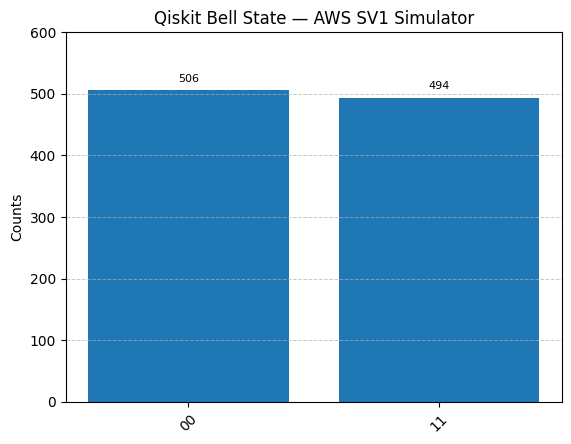

In [13]:
plot_histogram(qiskit_counts, title="Qiskit Bell State — AWS SV1 Simulator")

---

## Side-by-Side Comparison: Cirq vs Qiskit

Both circuits encode the same quantum operation (Bell state preparation). Since we ran them on an ideal simulator, we expect nearly identical results — both should show roughly 50/50 split between `|00>` and `|11>` with no other states appearing.

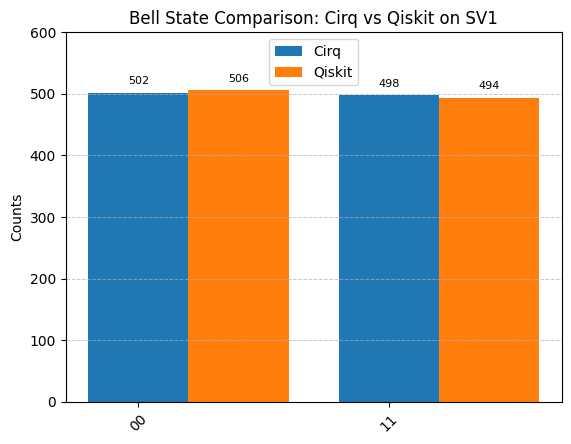

In [14]:
plot_histogram([cirq_counts, qiskit_counts], legend=["Cirq", "Qiskit"], title="Bell State Comparison: Cirq vs Qiskit on SV1")

---

## Key Takeaways

1. **qBraid abstracts away vendor differences** — you write circuits in your preferred library (Cirq, Qiskit, etc.) and qBraid handles transpilation to the target device's native format.

2. **Simulators provide ideal results** — on SV1, we see a perfect 50/50 split between `|00>` and `|11>` with no noise or errors.

3. **The execution pattern is always the same:**
   ```python
   device = provider.get_device("device_id")   # Select a device
   job = device.run(circuit, shots=N)           # Submit the job
   counts = job.result().data.get_counts()      # Get results
   ```

4. **Different libraries, same physics** — Cirq and Qiskit produced equivalent results because they encode the same quantum operations.

**Next up:** In Part 2, we'll run the same circuit on a *real* quantum computer and see how the results differ due to hardware noise.